# Logistic Regression Baseline Model

Objectives:
1. Load processed dataset.
2. Create train-test split.
3. Scale numerical features.
4. Train Logistic Regression model.
5. Evaluate model performance.
6. Analyze feature importance.
7. Establish baseline metrics.


### Section 2: Import Libraries


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns


### Section 3: Load Processed Dataset


In [2]:
df = pd.read_csv("../data/processed/model_data.csv")
print(df.shape)


(307511, 216)


### Section 4: Separate Features and Target


In [3]:
X = df.drop(columns=["TARGET"])
y = df["TARGET"]

print(X.shape)
print(y.shape)


(307511, 215)
(307511,)


### Section 5: Train-Test Split
Use stratification because the target is imbalanced.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [5]:
print(X_train.shape)
print(X_test.shape)


(246008, 215)
(61503, 215)


### Section 6: Feature Scaling
Logistic Regression benefits from scaling.


In [6]:
scaler = StandardScaler()

# Fit on training data:
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data:
X_test_scaled = scaler.transform(X_test)


### Section 7: Train Logistic Regression


In [7]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Section 8: Predictions


In [8]:
# Class prediction:
y_pred = model.predict(X_test_scaled)

# Probability prediction:
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]


### Section 9: Model Evaluation


In [9]:
auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {auc:.4f}")


ROC-AUC: 0.7482


In [10]:
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")


Precision: 0.1613


In [11]:
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")


Recall: 0.6767


In [12]:
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")


F1 Score: 0.2605


### Section 10: Classification Report


In [13]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



### Section 11: Confusion Matrix


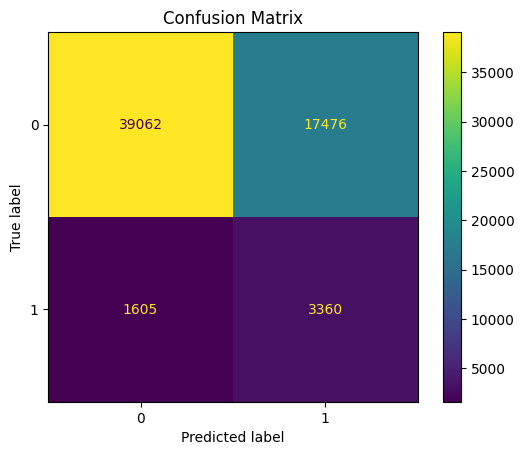

In [14]:
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot()
plt.title("Confusion Matrix")
plt.show()


### Section 12: ROC Curve


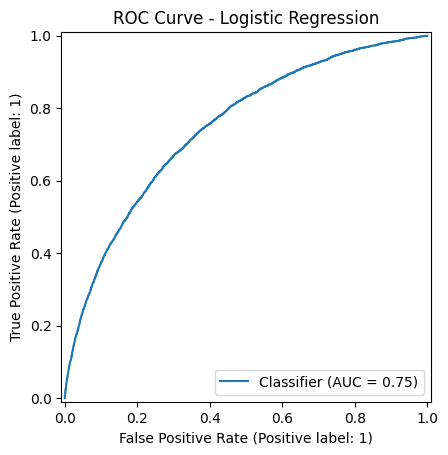

In [15]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title("ROC Curve - Logistic Regression")
plt.show()


### Section 13: Coefficient Analysis
Create feature importance table.


In [16]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})


In [17]:
coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

# Top positive coefficients:
print("Top Positive Coefficients:")
print(coef_df.head(20))


Top Positive Coefficients:
                                               Feature  Coefficient
115  NAME_EDUCATION_TYPE_Secondary / secondary special     0.468797
3                                           AMT_CREDIT     0.448227
49                                   BASEMENTAREA_MEDI     0.383702
112               NAME_EDUCATION_TYPE_Higher education     0.321223
37                                      LIVINGAREA_AVG     0.274922
58                            OBS_30_CNT_SOCIAL_CIRCLE     0.253344
52                                      ENTRANCES_MEDI     0.227327
95                                       CODE_GENDER_M     0.163422
30                                      APARTMENTS_AVG     0.160465
113              NAME_EDUCATION_TYPE_Incomplete higher     0.155819
19                         REGION_RATING_CLIENT_W_CITY     0.148323
64                                     FLAG_DOCUMENT_3     0.145439
42                                      ELEVATORS_MODE     0.143821
114                NA

In [18]:
# Top negative coefficients:
print("\nTop Negative Coefficients:")
print(coef_df.tail(20))



Top Negative Coefficients:
                                      Feature  Coefficient
187                  ORGANIZATION_TYPE_School    -0.069760
179                ORGANIZATION_TYPE_Military    -0.069945
18                       REGION_RATING_CLIENT    -0.070561
109                  NAME_INCOME_TYPE_Student    -0.078722
153  ORGANIZATION_TYPE_Business Entity Type 3    -0.079059
116                NAME_FAMILY_STATUS_Married    -0.085236
65                            FLAG_DOCUMENT_4    -0.090906
12                             FLAG_EMP_PHONE    -0.102826
33                              ELEVATORS_AVG    -0.118827
97                             FLAG_OWN_CAR_Y    -0.121119
48                            APARTMENTS_MEDI    -0.125530
107                NAME_INCOME_TYPE_Pensioner    -0.153148
27                               EXT_SOURCE_1    -0.180792
34                              ENTRANCES_AVG    -0.211182
60                   OBS_60_CNT_SOCIAL_CIRCLE    -0.241275
55                          

### Section 14: Feature Importance Visualization


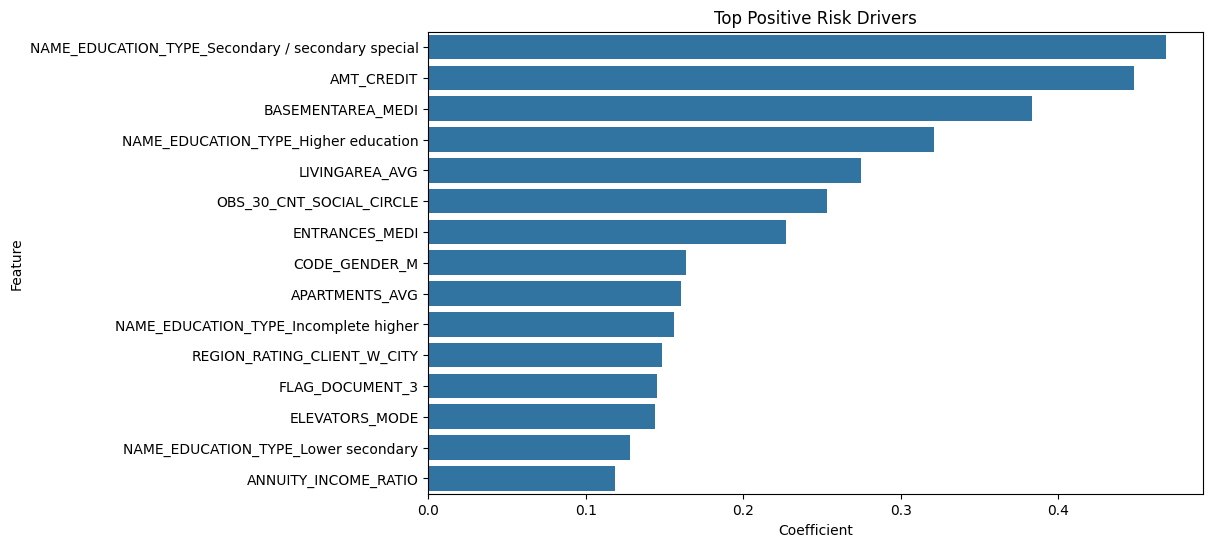

In [19]:
# Top positive risk drivers:
top_positive = coef_df.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x="Coefficient", y="Feature", data=top_positive)
plt.title("Top Positive Risk Drivers")
plt.show()


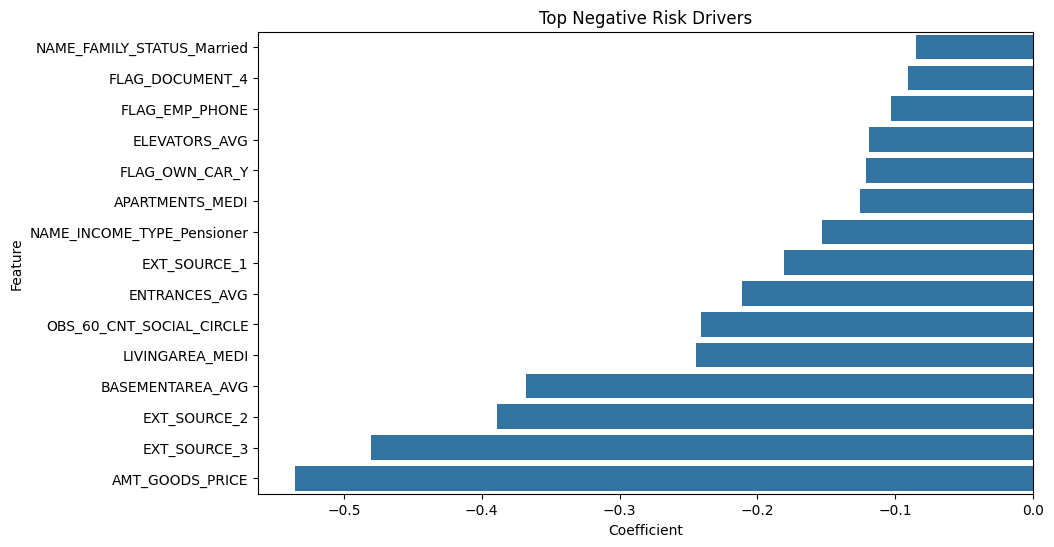

In [20]:
# Top protective features:
top_negative = coef_df.tail(15)

plt.figure(figsize=(10, 6))
sns.barplot(x="Coefficient", y="Feature", data=top_negative)
plt.title("Top Negative Risk Drivers")
plt.show()


## Business Interpretation

Positive coefficients increase the likelihood of default.
Negative coefficients decrease the likelihood of default.

The model provides interpretable insights into customer risk characteristics and serves as a baseline benchmark for more advanced models.


### Section 16: Save Model Metrics


In [21]:
metrics_df = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "ROC_AUC": [auc],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1]
})
metrics_df


,Model,ROC_AUC,Precision,Recall,F1
0,Logistic Regression,0.748174,0.161259,0.676737,0.260455


## Key Findings

1. Logistic Regression establishes a strong baseline.
2. The model is highly interpretable.
3. Class imbalance affects prediction performance.
4. Certain customer attributes significantly influence default risk.
5. More advanced tree-based models may improve predictive performance.

### Deliverables
* ✓ Train-Test Split
* ✓ Feature Scaling
* ✓ Logistic Regression Model
* ✓ ROC-AUC Evaluation
* ✓ Precision Evaluation
* ✓ Recall Evaluation
* ✓ F1 Evaluation
* ✓ Confusion Matrix
* ✓ ROC Curve
* ✓ Feature Importance Analysis
* ✓ Business Interpretation

This notebook establishes the baseline model against which XGBoost and LightGBM models will be compared in Notebook 5.
